<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 08 - Ejemplo 3 - Regresión lineal múltiple
        </td>
    </tr>
    <tr>
 

</table>

<h1>Ventas en Publicidad</h1>

Crear y evaluar un modelo de egresión lineal múltiple para predecir las ventas con datos simulados de una empresa dependiendo de las inversiones realizadas en publicidad.

- Analizar la relación entre cada variable predictora y la variable Sales mediante gráficos de dispersión.
- Construir el modelo de regresión lineal múltiple utilizando las variables `TV`, `Radio`, `Newspaper` y `Web`.
- Estimar los coeficientes del modelo e interpretar su significado.
- Evaluar el ajuste del modelo utilizando las siguientes métricas:
   - Coeficiente de determinación $R^2$.
   - Error cuadrático medio (MSE).
   - Raíz del error cuadrático medio (RMSE).
- Analizar la significancia estadística de las variables explicativas.
- Evaluar la posible multicolinealidad entre las variables predictoras mediante el Factor de Inflación de la Varianza (VIF) y los autovalores de la matriz de correlación
- Utilizar el modelo obtenido para realizar predicciones del volumen de ventas para nuevos niveles de inversión en publicidad.

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns  # Gráficos
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures # Polinomial
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
datos = pd.read_csv("https://raw.githubusercontent.com/rpizarrog/Analisis-Inteligente-de-datos/main/datos/Advertising_Web.csv")

In [3]:
datos

,Unnamed: 0,X,TV,Radio,Newspaper,Web,Sales
0,1,1,230.1,37.8,69.2,306.634752,22.1
1,2,2,44.5,39.3,45.1,302.653070,10.4
2,3,3,17.2,45.9,69.3,49.498908,9.3
3,4,4,151.5,41.3,58.5,257.816893,18.5
4,5,5,180.8,10.8,58.4,195.660076,12.9
...,...,...,...,...,...,...,...
195,196,196,38.2,3.7,13.8,248.841073,7.6
196,197,197,94.2,4.9,8.1,118.041856,9.7
197,198,198,177.0,9.3,6.4,213.274671,12.8
198,199,199,283.6,42.0,66.2,237.498063,25.5


In [7]:
#Eliminar columnas "Unnamed:0" y "X"
data = datos.drop(["Unnamed: 0","X"], axis=1)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Web        200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(5)
memory usage: 7.9 KB


Se describen las variables independientes: *TV, Radio, Newspaper* y *Web*.

Se describe la variable dependiente *Sales*: significa el volumen de ventas del producto correspondiente.

Para un solo producto en un mercado determinado, el costo de la publicidad, en miles, de las variables independientes:

-**TV**: costos de publicidad invertidos en TV.

-**Radio**: costos de publicidad invertidos en radio.

-**Periódico**: costos de publicidad invertidos en medios periodísticos.

-**Web**: costos de publicidad invertidos en páginas web.

In [9]:
data.describe()

,TV,Radio,Newspaper,Web,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,159.587355,14.022500
std,85.854236,14.846809,21.778621,76.815266,5.217457
min,0.700000,0.000000,0.300000,4.308085,1.600000
25%,74.375000,9.975000,12.750000,99.048767,10.375000
50%,149.750000,22.900000,25.750000,156.862154,12.900000
75%,218.825000,36.525000,45.100000,212.311848,17.400000
max,296.400000,49.600000,114.000000,358.247042,27.000000


In [10]:
data.head()

,TV,Radio,Newspaper,Web,Sales
0,230.1,37.8,69.2,306.634752,22.1
1,44.5,39.3,45.1,302.653070,10.4
2,17.2,45.9,69.3,49.498908,9.3
3,151.5,41.3,58.5,257.816893,18.5
4,180.8,10.8,58.4,195.660076,12.9


In [8]:
data.tail()

,TV,Radio,Newspaper,Web,Sales
195,38.2,3.7,13.8,248.841073,7.6
196,94.2,4.9,8.1,118.041856,9.7
197,177.0,9.3,6.4,213.274671,12.8
198,283.6,42.0,66.2,237.498063,25.5
199,232.1,8.6,8.7,151.990733,13.4


In [11]:
#crear matriz de correlación
corr = data.corr()
corr.style.background_gradient()

,TV,Radio,Newspaper,Web,Sales
TV,1.000000,0.054809,0.056648,0.012576,0.782224
Radio,0.054809,1.000000,0.354104,-0.122673,0.576223
Newspaper,0.056648,0.354104,1.000000,-0.057759,0.228299
Web,0.012576,-0.122673,-0.057759,1.000000,0.002108
Sales,0.782224,0.576223,0.228299,0.002108,1.000000


a) En esta sección se analiza la relación existente entre cada una de las variables predictoras (`TV`, `Radio`, `Newspaper` y `Web`) y la variable respuesta Sales mediante gráficos de dispersión.

Los gráficos de dispersión permiten visualizar la posible relación entre dos variables cuantitativas y observar patrones como tendencias lineales, dispersión de los datos o posibles valores atípicos. Este análisis exploratorio es útil para identificar qué variables podrían tener mayor influencia en el volumen de ventas y evaluar preliminarmente si un modelo de regresión lineal es adecuado para describir dichas relaciones.

A partir de estas representaciones gráficas se puede evaluar visualmente la fuerza y dirección de la relación entre cada inversión publicitaria y las ventas.

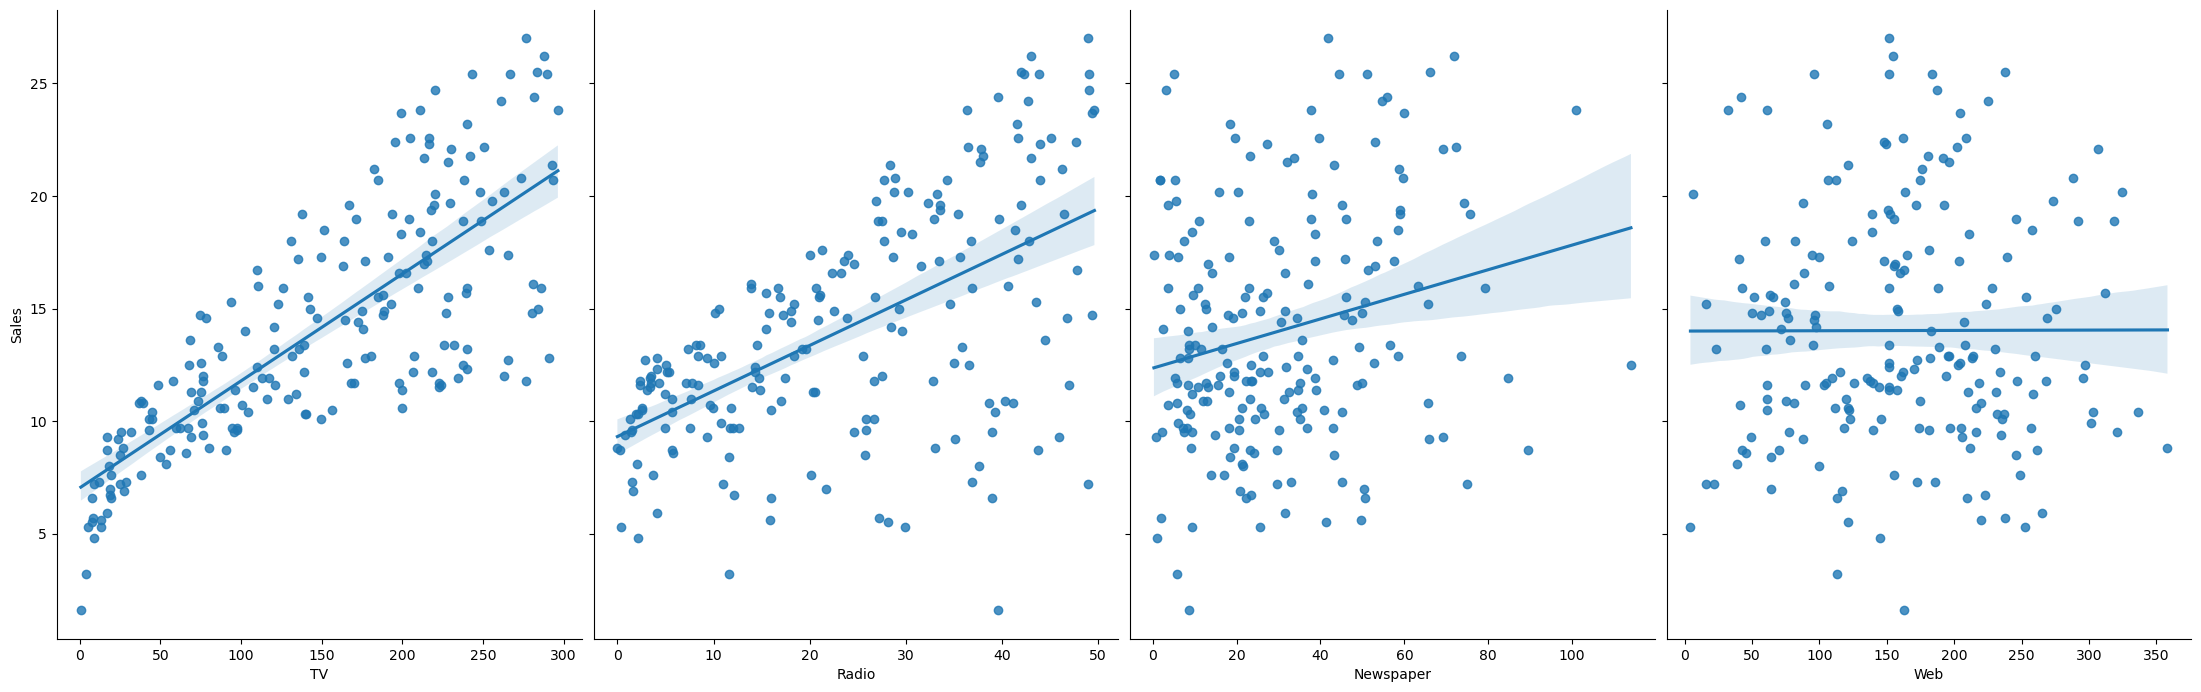

In [12]:
sns.pairplot(data, x_vars=['TV', 'Radio', 'Newspaper', 'Web'], y_vars='Sales', height=7, aspect=0.8, kind = 'reg')
plt.xlabel("Web")
plt.ylabel("Sales")
plt.show()

Se muestra las relaciones lineales entre las variables independientes con respecto a *Sales*.

Es posible estimar visualmente que la variable *Newspaper* tal vez tenga poco impacto en las *Sales*, esto por la alta dispersión de los datos. Sin embargo participará en el modelo de regresión lineal múltiple.

Se observa también que la variable *Web* tiene poca correlación lineal con la variable *Sales*.

b) En esta sección se construye un modelo de regresión lineal múltiple con el objetivo de analizar cómo las inversiones en distintos medios publicitarios influyen en el volumen de ventas del producto.

Para ello, se consideran como variables predictoras las inversiones en publicidad en televisión (`TV`), radio (`Radio`), periódicos (`Newspaper`) y plataformas web (`Web`). La variable respuesta es `Sales`, que representa el volumen de ventas.

In [13]:
# creamos un dataset con las variables predictoras
X_independientes = data[["TV","Radio","Newspaper","Web"]]
X_independientes.head()

,TV,Radio,Newspaper,Web
0,230.1,37.8,69.2,306.634752
1,44.5,39.3,45.1,302.653070
2,17.2,45.9,69.3,49.498908
3,151.5,41.3,58.5,257.816893
4,180.8,10.8,58.4,195.660076


In [14]:
# aislamos la variable respuesta
Y_dependiente = data["Sales"]
Y_dependiente.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [15]:
#se construye el modelo de regresión
modelo_rm = LinearRegression()

modelo_rm.fit(X_independientes, Y_dependiente)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# obtener coeficientes del modelo
# intercepto
print("El interceptor es %s" %modelo_rm.intercept_)

El interceptor es 2.244222199591782


In [18]:
# coeficientes de regresión
pd.DataFrame({"Variables": X_independientes.columns, "Coeficientes": modelo_rm.coef_})

#print(modelo_rm.coef_)

,Variables,Coeficientes
0,TV,0.045693
1,Radio,0.190975
2,Newspaper,-0.000794
3,Web,0.004016


Predicción: 

$$
Y=b_0+b_1⋅x_1+b_2⋅x_2+b_3⋅x_3+b_3⋅x_4
$$

Predicción de *Sales*: 

$$
\text{Sales}=b_0+b_1⋅\text{TV}+b_2⋅\text{Radio}+b_3⋅\text{Newspaper}+b_4⋅\text{Web}
$$

c) Evaluación del ajuste del modelo

Una vez estimado el modelo de regresión lineal múltiple, se evaluará su capacidad para explicar y predecir el comportamiento de la variable Sales. Para ello, se utilizarán las siguientes métricas de desempeño:

- Coeficiente de determinación ($R^2$): mide la proporción de la variabilidad de la variable dependiente que es explicada por el modelo. Valores cercanos a 1 indican un mejor ajuste.

- Error cuadrático medio (MSE): representa el promedio de los cuadrados de los errores entre los valores reales y los valores predichos por el modelo. Permite cuantificar la magnitud del error del modelo.

- Raíz del error cuadrático medio (RMSE): corresponde a la raíz cuadrada del MSE y se interpreta en las mismas unidades que la variable dependiente, lo que facilita la comprensión del error promedio de las predicciones.

In [21]:
#Calcular el R2
y_pred = modelo_rm.predict(X_independientes)
r_2 = r2_score(Y_dependiente, y_pred)

#Calculo de MSE
MSE = mean_squared_error(Y_dependiente, y_pred)

#Calcular RMSE
RMSE = np.sqrt(mse)

print("El coeficiente de determinacion es %.6f" %r_2)
print("El error cuadratico medio es %.6f" %MSE)
print("La raiz cuadrada del error cuadratico medio es %.6f" %RMSE)

El coeficiente de determinacion es 0.900652
El error cuadratico medio es 2.690922
La raiz cuadrada del error cuadratico medio es 1.640403


d) Una vez estimado el modelo de regresión lineal múltiple, se analizará la significancia estadística de las variables explicativas con el objetivo de determinar si cada una de ellas tiene un efecto relevante sobre la variable dependiente Sales.

Para ello, se examinarán los estadísticos t y los valores p (p-values) asociados a los coeficientes del modelo. Estos indicadores permiten evaluar la hipótesis:


In [22]:
# definir matriz de diseño y variable respuesta
X = X_independientes
y = Y_dependiente

# añadir intercepto
X2 = sm.add_constant(X)

# ajustar el modelo
est = sm.OLS(y, X2)

# ver ajuste
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     441.9
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.48e-96
Time:                        09:43:21   Log-Likelihood:                -382.78
No. Observations:                 200   AIC:                             775.6
Df Residuals:                     195   BIC:                             792.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2442      0.407      5.509      0.0

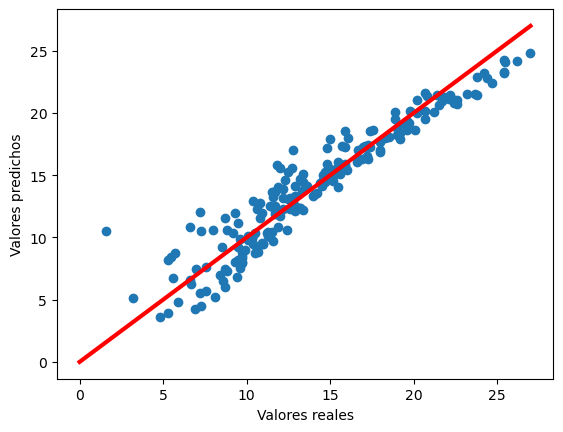

In [25]:
plt.figure()
plt.scatter(Y_dependiente, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.plot([np.min(X_independientes), np.max(Y_dependiente)],[np.min(X_independientes), np.max(Y_dependiente)],
         color = 'red', linewidth = 3)
plt.show()

In [26]:
# Variance Inflation Factor
#Crear dataframe para aplicar VIF
VIF = pd.DataFrame()
VIF["variable"] = X_independientes.columns

#Aplicar el método
VIF["VIF"] = [variance_inflation_factor(X_independientes.values, i) for i in range(len(X_independientes.columns))]

VIF

,variable,VIF
0,TV,3.172879
1,Radio,3.427062
2,Newspaper,3.191014
3,Web,3.088313


In [27]:
#Obtención de los autovalores de la matriz de correlación
corr_ind = X_independientes.corr()
av, v = np.linalg.eig(corr_ind)
AV = pd.DataFrame()
AV["Variable"] = X_independientes.columns
AV["Autovalor"] = av

AV

,Variable,Autovalor
0,TV,1.408008
1,Radio,1.013760
2,Newspaper,0.938592
3,Web,0.639639


In [28]:
#Vector con los valores de las variables independientes
pred_x = np.array([296.4, 49.6, 114, 358.247042])

prediccion = modelo_rm.predict(pred_x.reshape(1, -1))

print("El volumen de ventas que se espera es %s" %prediccion[0])

El volumen de ventas que se espera es 26.608175004034074


C:\Users\gus_r\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#lo que sigue pa abajo se descarta

In [23]:
print("Predicción: ", round(float(modelo_rm.predict ([[296.400000, 49.600000, 114.000000, 358.247042]])), 2))

Predicción:  26.61


C:\Users\gus_r\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\gus_r\AppData\Local\Temp\ipykernel_16708\3362170678.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Predicción: ", round(float(modelo_rm.predict ([[296.400000, 49.600000, 114.000000, 358.247042]])), 2))


In [ ]:
predicciones = modelo_rm.predict(X_independientes)

In [ ]:
comparaciones = pd.DataFrame(X_independientes)
comparaciones = comparaciones.assign(Sales_Real = Y_dependiente)
comparaciones = comparaciones.assign(Sales_Predicho = predicciones.flatten().tolist())
comparaciones.head()

,TV,Radio,Newspaper,Web,Sales_Real,Sales_Predicho
0,230.1,37.8,69.2,306.634752,22.1,21.153514
1,44.5,39.3,45.1,302.653070,10.4,12.962530
2,17.2,45.9,69.3,49.498908,9.3,11.939686
3,151.5,41.3,58.5,257.816893,18.5,18.042913
4,180.8,10.8,58.4,195.660076,12.9,13.307433


In [ ]:
# Variance Inflation Factor
# crear dataframe para aplicar VIF
VIF = pd.DataFrame()
VIF["variable"] = X_independientes.columns

In [ ]:
# aplicar el método
VIF["VIF"] = [variance_inflation_factor(X_independientes.values, i) for i in range(len(X_independientes.columns))]

# resultados
VIF

,variable,VIF
0,TV,3.172879
1,Radio,3.427062
2,Newspaper,3.191014
3,Web,3.088313


In [ ]:
#Ax, v = np.linalg.eig (corr)

Fin